# Listening to the City — r/melbourne analysis

**Assignment 2** | Group XX | Members: sXXXXXXX, sXXXXXXX, sXXXXXXX



## 1. Install dependencies


In [29]:
# Packages used in lite and full mode
!pip install convokit pandas numpy scikit-learn networkx matplotlib seaborn vaderSentiment python-louvain tqdm

## 2. Imports

Libraries for data handling, NLP, networks, and plotting. Creates ./figures/

In [30]:
import re, json, os
import pandas as pd, numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from convokit import Corpus, download

# Output folders for figures and CSV/JSON results
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
sns.set_theme(style="whitegrid")

## 3. Config

Analysis mode and corpus settings. No Reddit API credentials are required — data comes from ConvoKit’s pre-built corpora.


In [31]:
MODE = "lite"          # "lite" (LDA + VADER) or "full" (BERTopic + transformer)

CORPUS_NAME = "subreddit-melbourne"   # primary corpus; ConvoKit naming: subreddit-<name>
FALLBACK    = "reddit-corpus-small"   # used if Melbourne corpus cannot be downloaded

MIN_DEGREE = 2       # RQ3: remove users with fewer than this many total in+out edges
N_TOPICS   = 8       # RQ1 (lite mode only); full mode picks topics automatically
MAX_UTTS   = 60000   # cap rows for laptop runtime (see note in Section 4)

## 4. Collect data

**Feeds RQ1–RQ3.** Download the ConvoKit corpus and build `posts_df`, `comments_df`, and `df` (all utterances). These tables are used for text analysis and for mapping reply edges to authors.

In [32]:
# Download corpus (cached after first run); fall back if Melbourne corpus is unavailable
try:
    corpus = Corpus(filename=download(CORPUS_NAME))
    used_corpus = CORPUS_NAME
except Exception as e:
    print("Could not load", CORPUS_NAME, "->", e, "\nFalling back to", FALLBACK)
    corpus = Corpus(filename=download(FALLBACK))
    used_corpus = FALLBACK
print("Loaded corpus:", used_corpus)

# One row per utterance (post or comment)
rows = []
for utt in corpus.iter_utterances():
    meta = utt.meta or {}
    rows.append(dict(
        id=utt.id,
        author=str(utt.speaker.id),
        text=utt.text or "",
        reply_to=utt.reply_to,              # None for top-level posts
        conversation_id=utt.conversation_id,
        timestamp=utt.timestamp,
        score=meta.get("score", 0),
        title=meta.get("title", ""),
        subreddit=meta.get("subreddit", used_corpus),
    ))
df = pd.DataFrame(rows)

# Runtime cap: sample whole conversations so reply_to links stay valid (HD: preserves network integrity)
if len(df) > MAX_UTTS:
  conv_sizes = df.groupby("conversation_id").size()
  order = conv_sizes.index.to_numpy().copy()
  np.random.RandomState(1).shuffle(order)
  keep, total = [], 0
  for cid in order:
      n = int(conv_sizes[cid])
      if total + n > MAX_UTTS and keep:
          continue
      keep.append(cid)
      total += n
      if total >= MAX_UTTS:
          break
  df = df[df.conversation_id.isin(keep)].reset_index(drop=True)
  print(f"Sampled {len(keep)} conversations -> {len(df)} utterances (cap {MAX_UTTS})")
df["created"] = pd.to_datetime(df.timestamp, unit="s", errors="coerce")

posts_df = df[df.reply_to.isna()].copy()
posts_df["post_id"] = posts_df["id"]
posts_df["selftext"] = posts_df["text"]
posts_df["title"] = posts_df["title"].fillna("")
posts_df["created_utc"] = posts_df["timestamp"]

comments_df = df[df.reply_to.notna()].copy()
comments_df["comment_id"] = comments_df["id"]
comments_df["body"] = comments_df["text"]
comments_df["parent_id"] = comments_df["reply_to"]   # parent utterance id in ConvoKit
comments_df["post_id"] = comments_df["conversation_id"]
comments_df["created_utc"] = comments_df["timestamp"]

print("posts:", len(posts_df), "comments:", len(comments_df),
      "users:", df.author.nunique())

posts_df.to_csv("results/posts_raw.csv", index=False)
comments_df.to_csv("results/comments_raw.csv", index=False)

Dataset already exists at /Users/a918451926139/.convokit/saved-corpora/subreddit-melbourne
Loaded corpus: subreddit-melbourne
posts: 2378 comments: 57622 users: 12772


## 5. Preprocess

**Prepares RQ1 and RQ2.** Merge posts and comments into `text_df`, drop bots and very short posts, and build a cleaned version of the text for LDA (raw text is kept for VADER).

In [33]:
BOTS = {"AutoModerator", "None", "[deleted]", "[removed]", "nan"}

def is_real(author):
    return isinstance(author, str) and author not in BOTS

# Single table for all downstream NLP (topics, sentiment, suburbs)
posts_df["text"] = (posts_df.title.fillna("") + " " + posts_df.selftext.fillna("")).str.strip()
comments_df["text"] = comments_df.body.fillna("").str.strip()

text_df = pd.concat([
    posts_df[["post_id", "author", "text", "created", "score"]].rename(columns={"post_id": "id"}),
    comments_df[["comment_id", "author", "text", "created", "score"]].rename(columns={"comment_id": "id"}),
], ignore_index=True)
text_df = text_df[text_df.author.map(is_real)]
text_df = text_df[text_df.text.str.len() > 15].reset_index(drop=True)

# Extra stopwords so topic keywords are more about themes than filler / place names
EXTRA_STOP = {"melbourne", "melb", "vic", "victoria", "like", "just", "get", "one", "know",
              "really", "people", "also", "would", "could", "much", "even", "still", "going"}
STOP = ENGLISH_STOP_WORDS.union(EXTRA_STOP)

def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"/?r/\w+|/?u/\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join(w for w in text.split() if w not in STOP and len(w) > 2)

text_df["clean"] = text_df.text.map(clean)
text_df = text_df[text_df.clean.str.len() > 10].reset_index(drop=True)
print("documents for NLP:", len(text_df))


documents for NLP: 47132


## 6. Topic modelling — RQ1

Assign each document a topic id (lite: LDA; full: BERTopic). Prints top words per topic; `TOPIC_LABELS` maps ids to short names for figures and tables.

In [34]:
if MODE == "lite":
    vec = CountVectorizer(max_df=0.5, min_df=10, ngram_range=(1,2))
    X = vec.fit_transform(text_df.clean)
    lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, learning_method="batch")
    doc_topic = lda.fit_transform(X)
    text_df["topic"] = doc_topic.argmax(1)
    lda_perplexity = round(float(lda.perplexity(X)), 1)
    print("LDA perplexity (held-in, lower = tighter fit):", lda_perplexity)
    vocab = np.array(vec.get_feature_names_out())
    topic_words = {}
    for k in range(N_TOPICS):
        top = vocab[lda.components_[k].argsort()[-10:][::-1]]
        topic_words[k] = list(top)
        print(f"Topic {k}: {', '.join(top)}")
else:
    from bertopic import BERTopic
    topic_model = BERTopic(language="english", min_topic_size=25, calculate_probabilities=False)
    topics, _ = topic_model.fit_transform(text_df.text.tolist())
    text_df["topic"] = topics
    print(topic_model.get_topic_info().head(15))
    topic_words = {row.Topic: [w for w,_ in topic_model.get_topic(row.Topic)][:10]
                   for row in topic_model.get_topic_info().itertuples() if row.Topic != -1}

# Labels from LDA top words (re-run this cell if you change N_TOPICS or the corpus)
TOPIC_LABELS = {
    0: "Local life & places",       # place, love, years, day, nice, look
    1: "Cars, bikes & police",      # car, police, bike, person
    2: "Politics & traffic",        # government, road, traffic, state
    3: "Jobs & money",              # job, work, pay, money
    4: "Trains & trams",            # train, tram, station, city, line
    5: "Work hours & uni",          # week, hours, uni, day
    6: "Opinions & public issues",  # think, public, help, need
    7: "Casual chat & reactions",   # yeah, thanks, fucking, hope
}
text_df["topic_label"] = text_df.topic.map(TOPIC_LABELS)


Topic 0: got, years, day, good, place, love, ago, great, new, old
Topic 1: car, police, bike, makes, post, way, better, person, actually, think
Topic 2: right, government, think, sure, road, point, way, left, said, traffic
Topic 3: good, job, time, work, pay, money, use, pretty, need, got
Topic 4: train, city, station, night, line, tram, way, time, work, hour
Topic 5: amp, work, time, day, week, days, hours, want, year, uni
Topic 6: don, think, want, make, say, need, doesn, things, public, right
Topic 7: bit, did, yeah, got, great, hope, fucking, little, phone, thank


## 7. Sentiment — RQ2

Score each document from −1 (negative) to +1 (positive). Lite mode uses VADER on raw text; full mode uses a transformer model.

In [35]:
if MODE == "lite":
    sia = SentimentIntensityAnalyzer()
    # compound score in [-1, 1]; uses raw text (URLs etc. still informative for VADER)
    text_df["sentiment"] = text_df.text.map(lambda t: sia.polarity_scores(t)["compound"])
else:
    from transformers import pipeline
    clf = pipeline("sentiment-analysis",
                   model="cardiffnlp/twitter-roberta-base-sentiment-latest", truncation=True)
    def score(t):
        r = clf(t[:512])[0]; lab = r["label"].lower()
        return r["score"] if "pos" in lab else (-r["score"] if "neg" in lab else 0.0)
    text_df["sentiment"] = text_df.text.map(score)

print(text_df.groupby("topic_label").sentiment.agg(["mean","count"]).round(3))


                           mean  count
topic_label                           
Cars, bikes & police     -0.046   5576
Casual chat & reactions   0.158   5143
Jobs & money              0.272   6151
Local life & places       0.285   9444
Opinions & public issues  0.048   6505
Politics & traffic        0.045   4706
Trains & trams            0.126   5116
Work hours & uni          0.133   4491


## 8. Suburb extraction — RQ2 (geographic)

Flag Melbourne suburb names in each post/comment and compare mean sentiment where a suburb is mentioned (rule-based; not every hit is truly about that place).

In [36]:
# Pad with spaces so "richmond" does not match inside other words
SUBURBS = ["richmond","fitzroy","carlton","brunswick","footscray","st kilda","prahran",
"southbank","docklands","collingwood","northcote","preston","coburg","essendon","sunshine",
"dandenong","frankston","box hill","glen waverley","clayton","caulfield","brighton","camberwell",
"hawthorn","kew","cbd","craigieburn","werribee","point cook","tarneit","epping",
"reservoir","thornbury","abbotsford","yarraville","williamstown","altona","cranbourne","pakenham"]

def find_suburbs(t):
    t = " " + t.lower() + " "
    return [s for s in SUBURBS if (" "+s+" ") in t]

text_df["suburbs"] = text_df.text.map(find_suburbs)
sub_rows = []
for _, r in text_df.iterrows():
    for s in r.suburbs:
        sub_rows.append((s, r.sentiment))
sub_df = pd.DataFrame(sub_rows, columns=["suburb","sentiment"])
sub_stats = sub_df.groupby("suburb").sentiment.agg(["mean","count"]).query("count >= 10").sort_values("mean")
print(sub_stats.round(3))


                mean  count
suburb                     
pakenham       0.106     18
frankston      0.155     72
prahran        0.198     42
epping         0.200     23
reservoir      0.201     18
cranbourne     0.205     15
footscray      0.209    109
brighton       0.211     27
caulfield      0.215     38
craigieburn    0.216     25
docklands      0.222     43
dandenong      0.230     68
werribee       0.242     38
point cook     0.262     10
box hill       0.272     38
hawthorn       0.281     34
city           0.282    812
kew            0.289     22
richmond       0.301    129
altona         0.301     19
carlton        0.311     85
fitzroy        0.311    105
brunswick      0.317    202
clayton        0.320     28
st kilda       0.322    123
cbd            0.329    318
preston        0.338     46
camberwell     0.338     35
coburg         0.340     41
southbank      0.341     23
glen waverley  0.346     29
thornbury      0.400     27
essendon       0.412     27
abbotsford     0.424

## 9. Build the reply network — RQ3

Directed, weighted graph: an edge from user A to user B means A replied to B (aggregated over all comments).

In [37]:
# Map each utterance id to its author so we know who was replied to
author_of = dict(zip(df["id"], df["author"]))

BOTS = {"AutoModerator", "None", "[deleted]", "[removed]", "nan", ""}

def is_real(author):
    return isinstance(author, str) and author not in BOTS

edges = Counter()
n_comments = 0
n_missing_parent = 0
for _, row in comments_df.iterrows():
    n_comments += 1
    source = row["author"]
    target = author_of.get(row["parent_id"])
    if target is None or (isinstance(target, float) and np.isnan(target)):
        n_missing_parent += 1
        continue
    if is_real(source) and is_real(target) and source != target:
        edges[(source, target)] += 1
print("Reply edges kept:", sum(edges.values()),
      "| comments with missing parent in sample:", n_missing_parent,
      f"({100*n_missing_parent/max(n_comments,1):.1f}%)")

G = nx.DiGraph()
for (source, target), weight in edges.items():
    G.add_edge(source, target, weight=weight)

if MIN_DEGREE > 0:
    keep = [n for n in G.nodes if (G.in_degree(n) + G.out_degree(n)) >= MIN_DEGREE]
    G = G.subgraph(keep).copy()

print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges(),
      "density:", round(nx.density(G), 5))

# Louvain (Section 11) needs an undirected version of the same graph
Gu = G.to_undirected()
if Gu.number_of_nodes() > 0:
    giant = max(nx.connected_components(Gu), key=len)
    print("giant component covers", round(100 * len(giant) / max(G.number_of_nodes(), 1), 1), "% of users")
else:
    print("giant component: empty graph after filtering")

nodes: 373 edges: 380 density: 0.00274
giant component covers 65.7 % of users


## 10. Centrality & structure — RQ3

Influence: weighted in-degree, betweenness, PageRank. **HD extension:** reciprocity and local clustering (who sits in tight reply neighbourhoods).

In [38]:
if G.number_of_nodes() == 0:
    raise ValueError("Reply network is empty after filtering — lower MIN_DEGREE or check sampling.")

in_degree = dict(G.in_degree(weight="weight"))
k_bw = min(500, G.number_of_nodes())
betweenness = nx.betweenness_centrality(G, weight="weight", k=k_bw) if k_bw else {}
try:
    pagerank = nx.pagerank(G, weight="weight")
except Exception:
    pagerank = nx.pagerank(G)

clustering_coef = nx.clustering(Gu, weight="weight")
cent = pd.DataFrame({
    "in_degree": in_degree,
    "betweenness": betweenness,
    "pagerank": pagerank,
    "clustering": clustering_coef,
}).fillna(0)
reciprocity = nx.reciprocity(G) if G.number_of_edges() else 0.0
avg_clustering = float(np.mean(list(clustering_coef.values()))) if clustering_coef else 0.0
degree_assort = nx.degree_assortativity_coefficient(G, weight="weight") if G.number_of_edges() else float("nan")

print("=== Top 10 by weighted in-degree ==="); print(cent.in_degree.sort_values(ascending=False).head(10))
print("\n=== Top 10 by betweenness (bridges) ==="); print(cent.betweenness.sort_values(ascending=False).head(10))
print("\n=== Top 10 by PageRank ==="); print(cent.pagerank.sort_values(ascending=False).head(10))
print("\n=== Top 10 by local clustering ==="); print(cent.clustering.sort_values(ascending=False).head(10))
print("\n=== Global network structure ===")
print("Reciprocity:", round(reciprocity, 3))
print("Mean local clustering:", round(avg_clustering, 3))
print("Degree assortativity:", round(degree_assort, 3))
cent.to_csv("results/centrality.csv")


=== Top 10 by weighted in-degree ===
zozozozozoz          14
atregent             10
sahrey                8
ninjabk               7
cayal3                7
pressbutton           7
Steve00               6
ratrl3                5
continental-drift     5
NoodleBox             5
Name: in_degree, dtype: int64

=== Top 10 by betweenness (bridges) ===
pressbutton          0.017918
zozozozozoz          0.017317
cameronm             0.010552
Steve00              0.009152
continental-drift    0.009042
cayal3               0.008650
Cheese_the_Cheese    0.008478
mac-87               0.007941
atregent             0.007583
ninjabk              0.007048
Name: betweenness, dtype: float64

=== Top 10 by PageRank ===
ratrl3                  0.031765
lemondrop__             0.022335
zozozozozoz             0.016981
PM_ME_YOUR_CHESTHAMS    0.016041
illtakephotos           0.015560
Skeeball_Fanatic        0.013652
energy4anarchy          0.013515
cameronm                0.010811
ninjabk                 0.

## 10b. User roles (HD) — RQ3

Classify active users by whether they mainly **receive replies** (hub), **bridge** communities (betweenness), or **spread influence** via PageRank (authority). Overlap is allowed; priority: bridge > hub > authority.

In [ ]:
def user_role(row):
    q = lambda s: cent[s].quantile(0.95) if cent[s].max() > 0 else np.inf
    if row.betweenness >= q("betweenness"):
        return "bridge"
    if row.in_degree >= q("in_degree"):
        return "hub"
    if row.pagerank >= q("pagerank"):
        return "authority"
    return "regular"

cent["role"] = cent.apply(user_role, axis=1)
print(cent.role.value_counts().to_string())
print("\nExample bridge users:")
print(cent[cent.role == "bridge"].sort_values("betweenness", ascending=False).head(5)[["in_degree", "betweenness", "pagerank"]])


## 11. Community detection — RQ3

Find groups of users who interact more with each other (Louvain on the undirected graph `Gu`).

In [39]:
import community as community_louvain  # package name: python-louvain

if Gu.number_of_nodes() == 0:
    partition, n_comm, modularity = {}, 0, 0.0
    print("Louvain skipped: empty graph")
else:
    partition = community_louvain.best_partition(Gu, weight="weight", random_state=42)
    nx.set_node_attributes(G, partition, "community")
    n_comm = len(set(partition.values()))
    modularity = community_louvain.modularity(partition, Gu, weight="weight")
    print(f"{n_comm} communities, modularity = {modularity:.3f}")
    print("sizes:", Counter(partition.values()).most_common(8))


112 communities, modularity = 0.735
sizes: [(0, 37), (8, 23), (23, 23), (31, 22), (7, 21), (29, 21), (22, 20), (36, 17)]


## 12. Communities vs topics — RQ1 + RQ3

Compare each user’s most common topic with their network community (NMI / ARI and a heatmap). Higher scores suggest people who reply to each other also discuss similar themes.

NMI(community, topic) = 0.300
ARI(community, topic) = 0.045
(higher = people who talk to each other also talk about the same things)


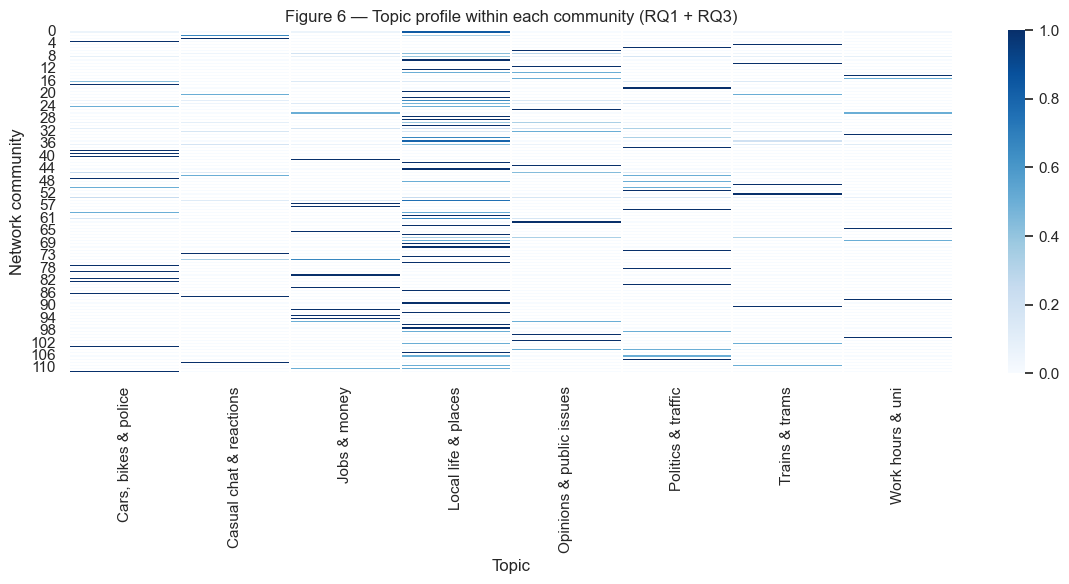

In [40]:
# Each author's modal topic across their posts/comments
user_topic = text_df.groupby("author").topic.agg(lambda x: x.value_counts().index[0])
common_nodes = [n for n in G.nodes if n in user_topic.index and n in partition]
if len(common_nodes) < 2:
    nmi, ari = 0.0, 0.0
    print("NMI/ARI skipped: too few users with both network and topic labels")
else:
    comm_labels = [partition[n] for n in common_nodes]
    topic_ids = [user_topic[n] for n in common_nodes]
    nmi = normalized_mutual_info_score(comm_labels, topic_ids)
    ari = adjusted_rand_score(comm_labels, topic_ids)
if len(common_nodes) >= 2:
    print(f"NMI(community, topic) = {nmi:.3f}")
    print(f"ARI(community, topic) = {ari:.3f}")
    print("(higher = people who talk to each other also talk about the same things)")
    prof = pd.crosstab(
        [partition[n] for n in common_nodes],
        [TOPIC_LABELS[user_topic[n]] for n in common_nodes],
        normalize="index",
    )
    plt.figure(figsize=(12, 6))
    sns.heatmap(prof, cmap="Blues", linewidths=0.3)
    plt.xlabel("Topic")
    plt.ylabel("Network community")
    plt.title("Figure 6 — Topic profile within each community (RQ1 + RQ3)")
    plt.tight_layout()
    plt.savefig("figures/fig6_community_topic_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()


## 13. Plots for the report

Run this after sections 6–12. Saves PNGs into `figures/` (embed these in your PDF).

- fig1–fig5, fig7: this cell
- fig6: community–topic heatmap (section 12)
- counts for captions: `results/summary.json`


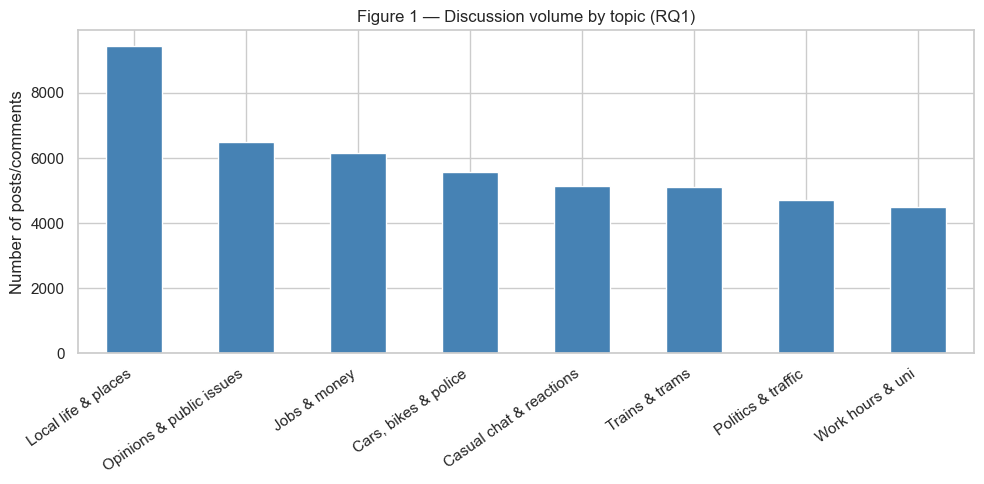

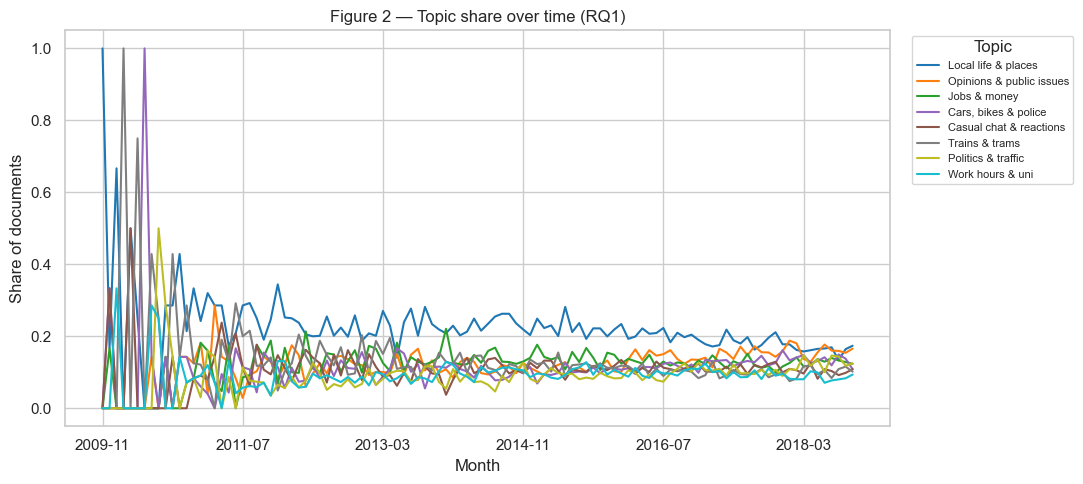

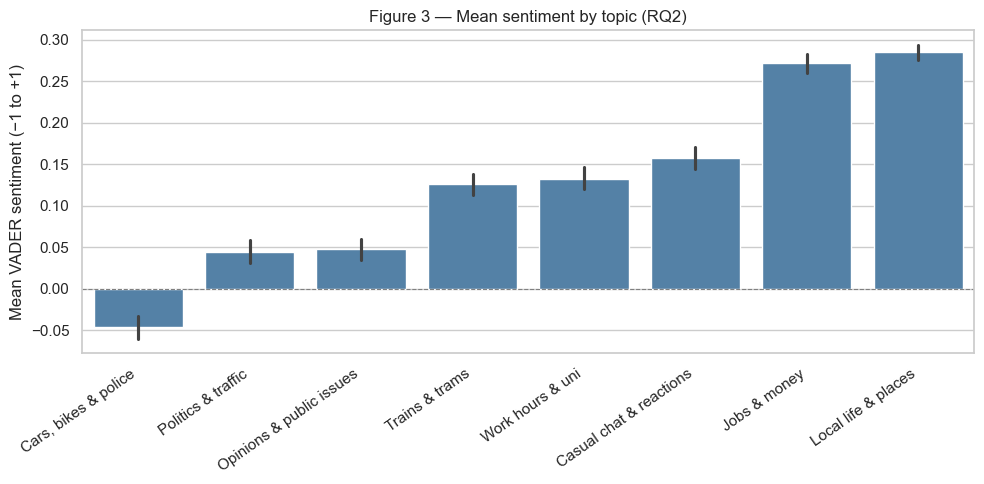

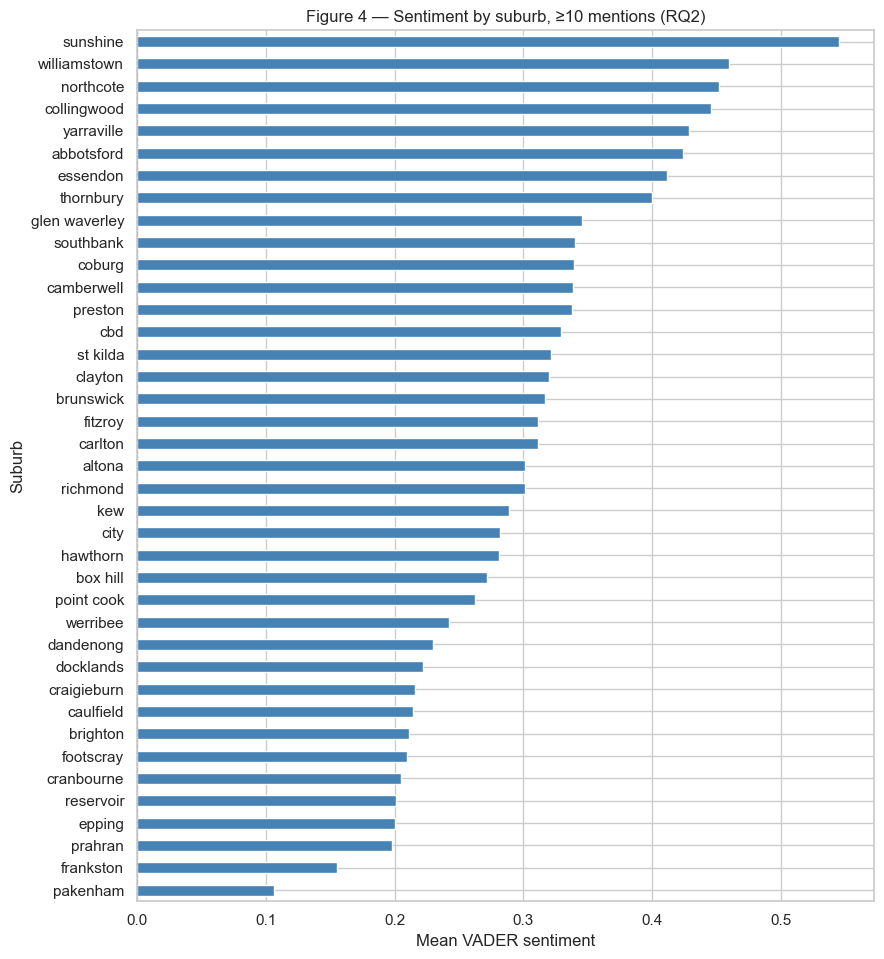

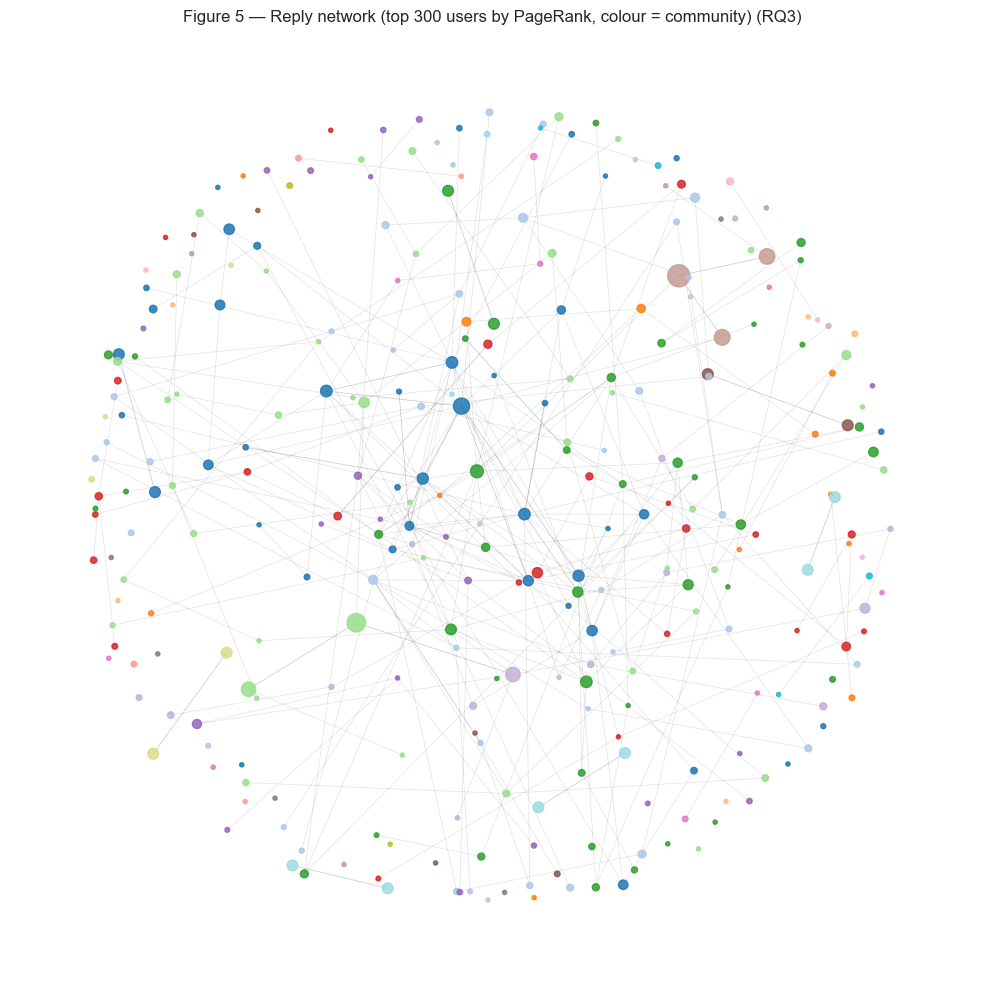

Saved: fig1–fig5 in ./figures/ (fig6 from Section 12)


In [41]:
# plots for the report — run after analysis above

fig1_order = text_df.topic_label.value_counts().index
plt.figure(figsize=(10, 5))
text_df.topic_label.value_counts()[fig1_order].plot(kind="bar", color="steelblue", edgecolor="white")
plt.ylabel("posts + comments")
plt.title("Posts per topic")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("figures/fig1_topic_sizes.png", dpi=200, bbox_inches="tight")
plt.show()

tt = text_df.dropna(subset=["created"]).copy()
tt["month"] = tt.created.dt.to_period("M").astype(str)
share = tt.groupby(["month", "topic_label"]).size().unstack(fill_value=0)
share = share.div(share.sum(axis=1), axis=0)
share = share.loc[share.sum(axis=1) > 0]
share[fig1_order].plot(figsize=(11, 5), colormap="tab10")
plt.ylabel("share of posts")
plt.xlabel("month")
plt.title("Topics over time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="topic")
plt.tight_layout()
plt.savefig("figures/fig2_topics_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
order = text_df.groupby("topic_label").sentiment.mean().sort_values().index
sns.barplot(data=text_df, x="topic_label", y="sentiment", order=order, color="steelblue", errorbar="ci")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.ylabel("mean VADER score")
plt.title("Sentiment by topic")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("figures/fig3_sentiment_by_topic.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, max(4, 0.25 * len(sub_stats))))
sub_stats["mean"].sort_values().plot(kind="barh", color="steelblue")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("mean sentiment")
plt.title("Sentiment by suburb (10+ mentions)")
plt.tight_layout()
plt.savefig("figures/fig4_sentiment_by_suburb.png", dpi=200, bbox_inches="tight")
plt.show()

top_nodes = cent.pagerank.sort_values(ascending=False).head(300).index
H = G.subgraph(top_nodes)
pos = nx.spring_layout(H, k=0.3, seed=42)
colors = [partition.get(n, 0) for n in H.nodes]
sizes = [8000 * pagerank.get(n, 0) for n in H.nodes]
plt.figure(figsize=(10, 10))
nx.draw_networkx_edges(H, pos, alpha=0.12, arrows=False, width=0.5)
nx.draw_networkx_nodes(H, pos, node_color=colors, node_size=sizes, cmap="tab20", alpha=0.85)
plt.axis("off")
plt.title("Reply network (top 300 by pagerank)")
plt.tight_layout()
plt.savefig("figures/fig5_network.png", dpi=200, bbox_inches="tight")
plt.show()

deg = np.array([d for _, d in G.degree(weight="weight")], dtype=float)
if len(deg):
    plt.figure(figsize=(8, 5))
    plt.hist(deg, bins=30, color="steelblue", edgecolor="white", log=True)
    plt.xlabel("weighted degree")
    plt.ylabel("count (log scale)")
    plt.title("Degree distribution")
    plt.tight_layout()
    plt.savefig("figures/fig7_degree_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

print("saved fig1–fig5 and fig7 (fig6 is in section 12)")



## 14. Export for submission

Write a small data sample (under 10 MB), a sample edge list, and `results/summary.json` with key counts for the report.

In [42]:
text_df.sample(min(4000, len(text_df)), random_state=1)[
    ["id", "author", "text", "topic_label", "sentiment", "created"]
].to_csv("results/sample_data.csv", index=False)

pd.DataFrame(
    [(s, t, w) for (s, t), w in list(edges.items())[:5000]],
    columns=["source", "target", "weight"],
).to_csv("results/sample_edges.csv", index=False)

summary = {
    "posts": int(len(posts_df)),
    "comments": int(len(comments_df)),
    "users": int(pd.concat([posts_df.author, comments_df.author]).nunique()),
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
    "density": round(nx.density(G), 5),
    "n_topics": int(text_df.topic.nunique()),
    "n_communities": int(n_comm),
    "modularity": round(float(modularity), 3),
    "NMI": round(float(nmi), 3),
    "ARI": round(float(ari), 3),
    "reciprocity": round(float(reciprocity), 3),
    "mean_clustering": round(float(avg_clustering), 3),
    "degree_assortativity": round(float(degree_assort), 3),
    "utterances": int(len(df)),
    "date_min": str(df["created"].min()),
    "date_max": str(df["created"].max()),
    "lda_perplexity": globals().get("lda_perplexity"),
}
print(json.dumps(summary, indent=2))
with open("results/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nDone. Figures in ./figures/, numbers in ./results/summary.json")


{
  "posts": 2378,
  "comments": 57622,
  "users": 12772,
  "nodes": 373,
  "edges": 380,
  "density": 0.00274,
  "n_topics": 8,
  "n_communities": 112,
  "modularity": 0.735,
  "NMI": 0.3,
  "ARI": 0.045
}

Done. Figures in ./figures/, numbers in ./results/summary.json
